In [81]:
import sys
from pathlib import Path
import datetime as dt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from py_eddy_tracker.observations.tracking import TrackEddiesObservations

EXPERIMENT = "gulf_stream_20241001_20250701"
COLORS = {"cyclone": "tab:blue", "anticyclone": "tab:red"}

In [82]:
def haversine_km(lon1, lat1, lon2, lat2):
    """Vectorized great-circle distance in km."""
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

## Load data

Number of observations across all eddy polarities across all days, for eddies which have a lifetime of over 60 days (see config)

In [83]:
frames = []
for polarity in ("cyclone", "anticyclone"):
    pigments_dir = ROOT / "outputs" / EXPERIMENT / "pigments" / polarity
    for fp in sorted(pigments_dir.glob("eddy_*_pigments.parquet")):
        df = pd.read_parquet(fp)
        df["polarity"] = polarity
        frames.append(df)

pigments = pd.concat(frames, ignore_index=True)
meta_cols = ["track_id", "date", "pixel_lon", "pixel_lat", "center_lon", "center_lat", "coverage"]
pigment_cols = [c for c in pigments.columns if c not in meta_cols + ["polarity"]]

Pigments: one row per pixel for each eddy on each day

In [84]:
pigments

,track_id,date,pixel_lon,pixel_lat,center_lon,center_lat,coverage,T chla,Zea,DV chla,...,HexFuco,Allo,MV chlb,Neo,Viola,Fuco,chl c1+c2,chl c3,Perid,polarity
0,0,2024-12-29,-65.437500,36.479164,-65.041718,36.119770,0.986523,0.477786,0.061293,0.032487,...,0.111322,0.015341,0.067113,0.007245,0.010744,0.094334,0.067489,0.041876,0.016612,cyclone
1,0,2024-12-29,-65.395828,36.479164,-65.041718,36.119770,0.986523,0.337800,0.052824,0.029218,...,0.093035,0.011313,0.052392,0.004967,0.008314,0.060714,0.044057,0.031623,0.015815,cyclone
2,0,2024-12-29,-65.354164,36.479164,-65.041718,36.119770,0.986523,0.271989,0.050887,0.034024,...,0.078251,0.005750,0.041078,0.003236,0.005416,0.046406,0.037295,0.025831,0.014613,cyclone
3,0,2024-12-29,-65.312500,36.479164,-65.041718,36.119770,0.986523,0.440008,0.058140,0.031560,...,0.103443,0.011856,0.058122,0.006049,0.008442,0.089423,0.060635,0.040142,0.016301,cyclone
4,0,2024-12-29,-65.270828,36.479164,-65.041718,36.119770,0.986523,0.503517,0.060851,0.027689,...,0.111668,0.014505,0.064445,0.007202,0.010205,0.100654,0.069113,0.045689,0.016461,cyclone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471300,9,2025-02-27,-61.020828,41.145832,-61.090424,41.488132,1.000000,0.786183,0.053991,0.028098,...,0.188860,0.038187,0.124782,0.017176,0.023220,0.096665,0.098563,0.075213,0.009971,anticyclone
471301,9,2025-02-27,-60.979164,41.145832,-61.090424,41.488132,1.000000,0.681864,0.061061,0.029109,...,0.173854,0.031275,0.106406,0.013926,0.019480,0.083372,0.088668,0.065037,0.012446,anticyclone
471302,9,2025-02-27,-60.937496,41.145832,-61.090424,41.488132,1.000000,0.444707,0.054371,0.031038,...,0.136135,0.019904,0.072554,0.007857,0.013345,0.046889,0.063112,0.046057,0.014459,anticyclone
471303,9,2025-02-27,-60.895828,41.145832,-61.090424,41.488132,1.000000,0.190760,0.064606,0.052333,...,0.098041,0.010685,0.046670,0.003685,0.008722,0.000000,0.022216,0.023368,0.011352,anticyclone


In [85]:
def load_track_props(polarity):
    PET_EPOCH = dt.date(1950, 1, 1)
    zarr_path = ROOT / "outputs" / EXPERIMENT / "eddy_track" / polarity / f"{polarity}_tracks.zarr"
    tracked = TrackEddiesObservations.load_file(str(zarr_path))

    unique_ids = np.unique(tracked.track)
    lifetime = {}
    for tid in unique_ids:
        t = tracked.time[tracked.track == tid]
        lifetime[tid] = int(t.max() - t.min()) + 1

    dates = [PET_EPOCH + dt.timedelta(days=int(d)) for d in tracked.time]
    return pd.DataFrame({
        "track_id": tracked.track.astype(int),
        "date": pd.to_datetime(dates),
        "polarity": polarity,
        "center_lon": (tracked.longitude + 180) % 360 - 180,
        "center_lat": tracked.latitude,
        "radius_km": tracked.radius_e / 1000,
        "amplitude_m": tracked.amplitude,
        "speed_avg": tracked.speed_average,
        "lifetime_days": [lifetime[tid] for tid in tracked.track],
    })

track_properties = pd.concat(
    [load_track_props(p) for p in ("cyclone", "anticyclone")],
    ignore_index=True,
)
print(track_properties.groupby("polarity")["track_id"].nunique())

polarity
anticyclone    35
cyclone        44
Name: track_id, dtype: int64


Track: one row per eddy per day

In [86]:
track_properties

,track_id,date,polarity,center_lon,center_lat,radius_km,amplitude_m,speed_avg,lifetime_days
0,0,2024-10-01,cyclone,-59.404602,36.163452,101.050003,0.2130,0.3525,125
1,0,2024-10-02,cyclone,-59.444305,36.140678,104.550003,0.2128,0.3403,125
2,0,2024-10-03,cyclone,-59.477478,36.141560,103.800003,0.2045,0.3233,125
3,0,2024-10-04,cyclone,-59.516479,36.144691,102.800003,0.1986,0.3120,125
4,0,2024-10-05,cyclone,-59.564453,36.148300,106.650002,0.2030,0.3121,125
...,...,...,...,...,...,...,...,...,...
8289,34,2025-06-23,anticyclone,-70.501740,31.813038,39.549999,0.0395,0.2133,61
8290,34,2025-06-24,anticyclone,-70.490662,31.797588,34.849998,0.0347,0.2079,61
8291,34,2025-06-25,anticyclone,-70.483551,31.782907,40.750000,0.0363,0.1998,61
8292,34,2025-06-26,anticyclone,-70.479614,31.766027,39.549999,0.0306,0.1856,61


In [87]:
pigments = pigments.merge( # left join pigments and eddy tracking data
    track_properties[["track_id", "date", "polarity",
           "radius_km", "amplitude_m", "speed_avg", "lifetime_days"]],
    on=["track_id", "date", "polarity"],
    how="left",
)

pigments["dist_km"] = haversine_km(
    pigments["pixel_lon"].values, pigments["pixel_lat"].values,
    pigments["center_lon"].values, pigments["center_lat"].values,
)

# Obtain a normalized distance in terms of distance to eddy center
pigments["r_norm"] = pigments["dist_km"] / pigments["radius_km"]


## Overall stats about cyclonic vs anticyclonic eddies

In [88]:
summary = (
    pigments.groupby("polarity")
    .apply(lambda g: pd.Series({
        "eddies": g["track_id"].nunique(),
        "eddy-dates": g.groupby("track_id")["date"].nunique().sum(),
        "pixels": len(g),
        "median lifetime (d)": g.drop_duplicates("track_id")["lifetime_days"].median(),
        "median radius (km)": g["radius_km"].median(),
        "median amplitude (m)": g["amplitude_m"].median(),
    }), include_groups=False)
)
summary

,eddies,eddy-dates,pixels,median lifetime (d),median radius (km),median amplitude (m)
polarity,,,,,,
anticyclone,34.0,307.0,165752.0,87.5,80.949997,0.0868
cyclone,42.0,509.0,305553.0,84.5,91.849998,0.2298


Distinct eddy-date pairings carried through each stage of the PACE pipeline. Tracked and pigment counts are consistent with the local notebook data; the intermediate `PACE file available` and `collocated RRS` counts come from the PACE ICE audit of the scratch-backed run archive. Bars are stacked by polarity to show both the total cut and the cyclone-anticyclone split.

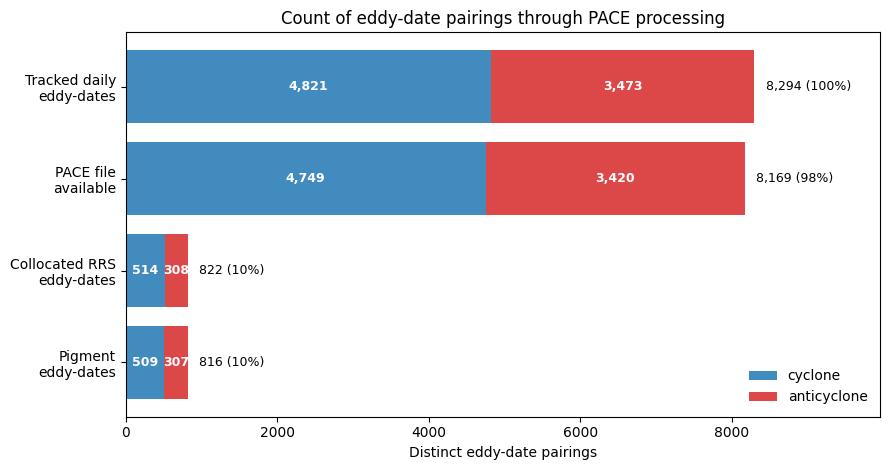

In [100]:
stage_counts = pd.DataFrame({
    "stage": [
        "Tracked daily\neddy-dates",
        "PACE file\navailable",
        "Collocated RRS\neddy-dates",
        "Pigment\neddy-dates",
    ],
    "cyclone": [4821, 4749, 514, 509],
    "anticyclone": [3473, 3420, 308, 307],
})
stage_counts["total"] = stage_counts["cyclone"] + stage_counts["anticyclone"]
stage_counts["pct_of_tracked"] = stage_counts["total"] / stage_counts.loc[0, "total"]
stage_counts

fig, ax = plt.subplots(figsize=(9, 4.8))
left = np.zeros(len(stage_counts))

for polarity in ("cyclone", "anticyclone"):
    vals = stage_counts[polarity].to_numpy()
    ax.barh(stage_counts["stage"], vals, left=left, color=COLORS[polarity], alpha=0.85, label=polarity)

    for i, (start, val) in enumerate(zip(left, vals)):
        if val >= 250:
            ax.text(start + val / 2, i, f"{val:,}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")

    left = left + vals

for i, (total, pct) in enumerate(zip(stage_counts["total"], stage_counts["pct_of_tracked"])):
    ax.text(total + 150, i, f"{total:,} ({pct:.0%})", va="center", fontsize=9)

ax.set_xlabel("Distinct eddy-date pairings")
ax.set_title("Count of eddy-date pairings through PACE processing")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(0, stage_counts["total"].max() * 1.20)
ax.invert_yaxis()
fig.tight_layout()


In [90]:
# Obtain mean pigments in an eddy for a particular day
eddy_means = (
    pigments.groupby(["track_id", "date", "polarity"])[pigment_cols]
    .mean()
    .reset_index()
)
eddy_means[eddy_means['track_id'] == 0]

,track_id,date,polarity,T chla,Zea,DV chla,ButFuco,HexFuco,Allo,MV chlb,Neo,Viola,Fuco,chl c1+c2,chl c3,Perid
0,0,2024-10-03,anticyclone,0.024673,0.011319,0.006666,0.001367,0.003247,0.000086,0.000272,0.000091,0.000047,0.016785,0.005443,0.001809,0.001094
1,0,2024-10-13,anticyclone,0.147616,0.004959,0.004573,0.009522,0.032335,0.004024,0.012398,0.002492,0.002015,0.033587,0.023843,0.014794,0.001077
2,0,2024-10-21,anticyclone,0.115086,0.017114,0.008914,0.005372,0.017182,0.001203,0.003463,0.000993,0.000495,0.035169,0.018896,0.009696,0.001132
3,0,2024-10-26,anticyclone,0.072039,0.020272,0.016314,0.004122,0.013807,0.001125,0.003334,0.000692,0.000615,0.022734,0.012144,0.006302,0.002031
4,0,2024-11-02,anticyclone,0.260908,0.033486,0.016922,0.013738,0.051823,0.007522,0.023082,0.003932,0.004615,0.054167,0.038239,0.023028,0.002005
5,0,2024-11-15,anticyclone,0.154992,0.036649,0.025010,0.011499,0.038008,0.003588,0.015984,0.002199,0.002685,0.026648,0.021245,0.013213,0.005098
6,0,2024-11-22,anticyclone,0.176703,0.016784,0.008446,0.012577,0.040323,0.004768,0.018069,0.002724,0.003177,0.035342,0.025513,0.016002,0.002214
7,0,2024-12-17,anticyclone,0.022039,0.037624,0.035622,0.006452,0.017492,0.000377,0.002848,0.000160,0.000433,0.001872,0.002035,0.002098,0.005697
8,0,2024-12-25,anticyclone,0.193775,0.057726,0.038931,0.018088,0.058101,0.006423,0.029327,0.002834,0.005112,0.016463,0.021178,0.015715,0.007916
9,0,2024-12-29,cyclone,0.427810,0.058545,0.035189,0.029699,0.106095,0.013276,0.057544,0.006156,0.009001,0.081920,0.059854,0.040337,0.015748


Distribution of per-eddy-date mean T chla for cyclonic (blue) and anticyclonic (red) eddies. Each value is the spatial mean across all PACE pixels within one eddy on one day. Density-normalized histograms allow comparison despite unequal sample sizes between polarities.

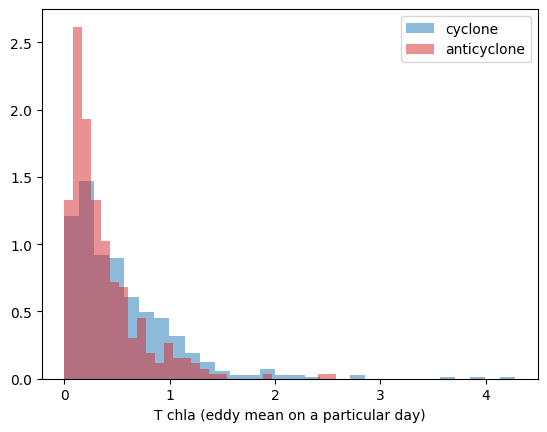

In [91]:
fig, ax = plt.subplots()
for pol in ("cyclone", "anticyclone"):
    vals = eddy_means.loc[eddy_means["polarity"] == pol, "T chla"]
    ax.hist(vals, bins=30, alpha=0.5, label=pol, color=COLORS[pol], density=True)
ax.set_xlabel("T chla (eddy mean on a particular day)")
ax.legend()

## Radial pigment profiles

In [92]:
RADIAL_BINS = [0, 0.25, 0.5, 0.75, 1.0, 1.5]

bin_mids = [(RADIAL_BINS[i] + RADIAL_BINS[i+1]) / 2 for i in range(len(RADIAL_BINS) - 1)]
bin_labels = [f"{RADIAL_BINS[i]:.2f}-{RADIAL_BINS[i+1]:.2f}"
              for i in range(len(RADIAL_BINS) - 1)]

pigments["r_bin"] = pd.cut(pigments["r_norm"], bins=RADIAL_BINS, labels=bin_labels, right=False)
pig_binned = pigments.dropna(subset=["r_bin"])

In [93]:
def radial_profile(df, col, n_boot=1000):
    grouped = (df.groupby(["track_id", "date", "r_bin"], observed=True)[col]
               .mean().reset_index())

    means, lo, hi = [], [], []
    for label in bin_labels:
        vals = grouped.loc[grouped["r_bin"] == label, col].values
        if len(vals) < 3:
            means.append(np.nan); lo.append(np.nan); hi.append(np.nan)
            continue
        res = stats.bootstrap((vals,), np.mean, n_resamples=n_boot,
                              confidence_level=0.95, method="percentile")
        means.append(vals.mean())
        lo.append(res.confidence_interval.low)
        hi.append(res.confidence_interval.high)
    return np.array(means), np.array(lo), np.array(hi)

Mean diagnostic-pigment concentration as a function of normalized radial distance (r/R), with 95% bootstrap confidence intervals. Radial bins span 0–0.25, 0.25–0.5, 0.5–0.75, 0.75–1.0, and 1.0–1.5 effective radii. Each bin value averages per-eddy-date bin means, weighting eddies equally.

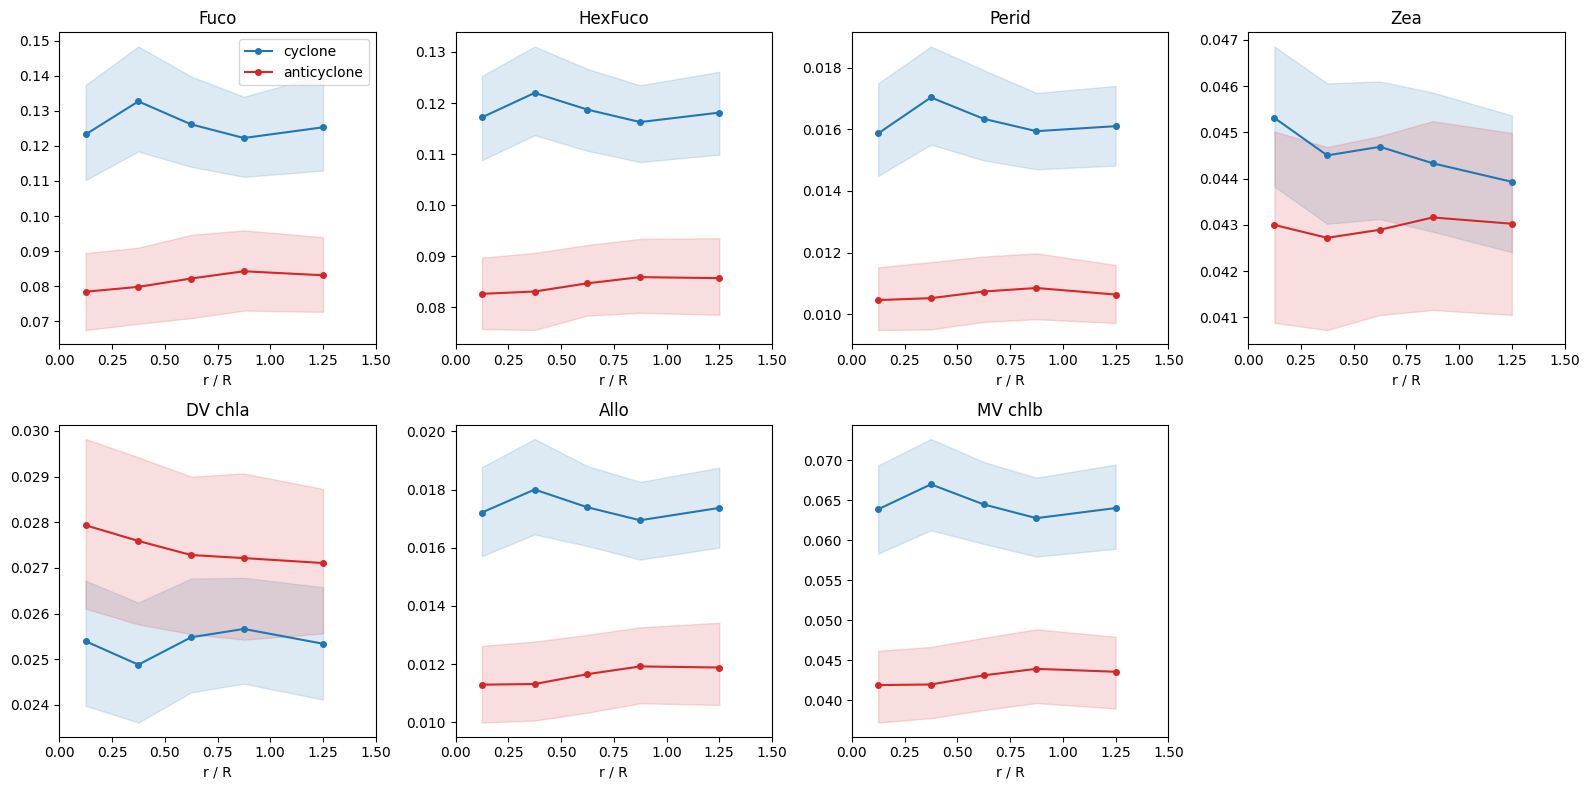

In [94]:
DIAGNOSTIC_PIGMENTS = [
    "Fuco", # diatoms
    "HexFuco", # haptophytes
    "Perid", # dinoflagellates
    "Zea", # cyanobacteria
    "DV chla", # prochlorococcus
    "Allo", # cryptophytes
    "MV chlb", # green algae
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
x = np.array(bin_mids)

for i, col in enumerate(DIAGNOSTIC_PIGMENTS):
    ax = axes.flat[i]
    for pol in ("cyclone", "anticyclone"):
        subset = pig_binned[pig_binned["polarity"] == pol]
        m, lo, hi = radial_profile(subset, col)
        ax.plot(x, m, "o-", color=COLORS[pol], label=pol, ms=4)
        ax.fill_between(x, lo, hi, color=COLORS[pol], alpha=0.15)
    ax.set_title(col)
    ax.set_xlabel("r / R")
    ax.set_xlim(0, 1.5)

axes.flat[0].legend()
axes.flat[-1].set_visible(False)
fig.tight_layout()

Radial profiles of PhytoClass PFT concentrations, constructed identically to the diagnostic-pigment profiles above. Shaded bands show 95% bootstrap CIs on the bin mean. Divergence between cyclonic and anticyclonic profiles indicates polarity-dependent PFT gradients beyond a total-biomass effect.

471305 pixels, 76 eddies


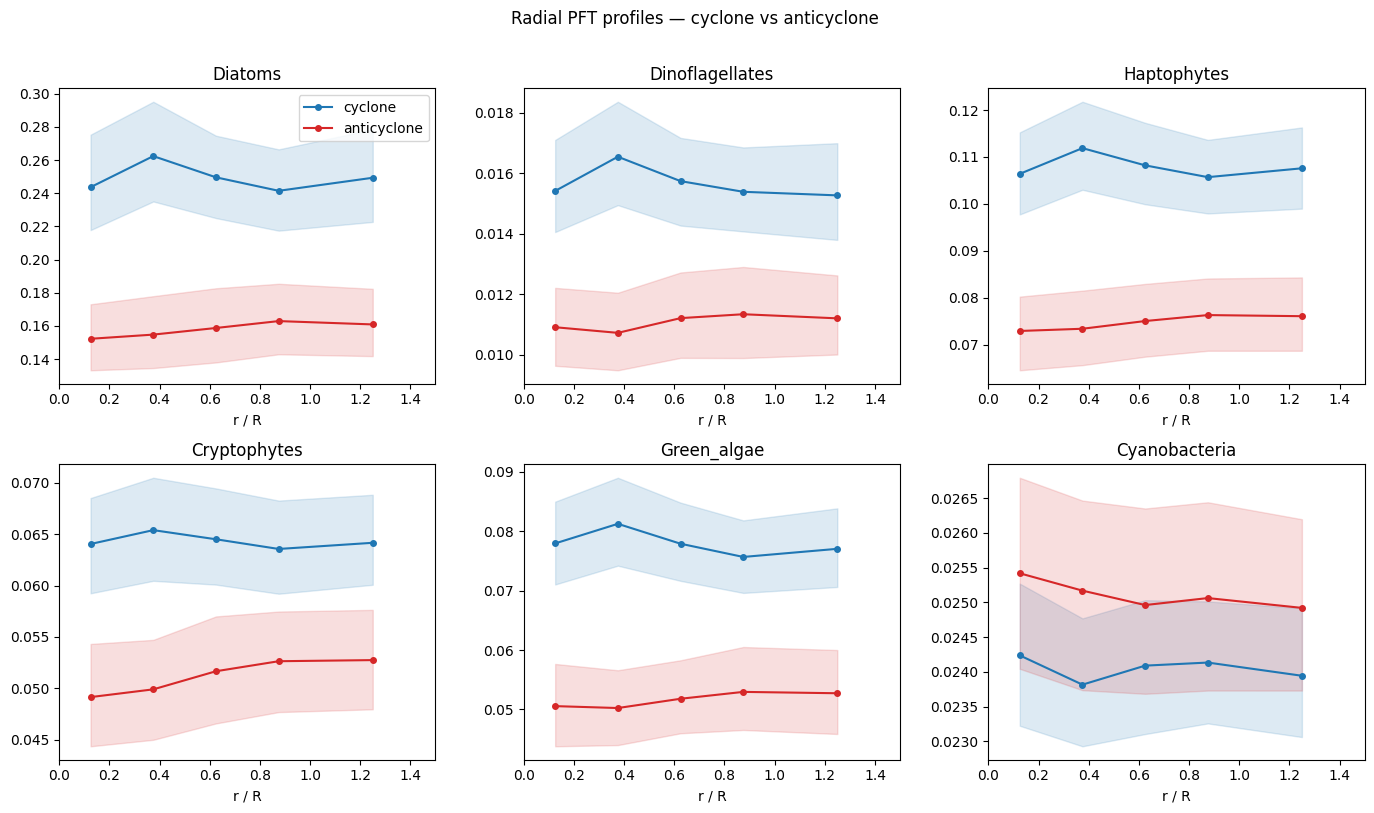

In [95]:
# Load PFT data
pft_frames = []
for polarity in ("cyclone", "anticyclone"):
    pft_dir = ROOT / "outputs" / EXPERIMENT / "pft" / polarity
    for fp in sorted(pft_dir.glob("eddy_*_pfts.parquet")):
        df = pd.read_parquet(fp)
        df["polarity"] = polarity
        pft_frames.append(df)

pfts = pd.concat(pft_frames, ignore_index=True)
PFT_COLS = ["Diatoms", "Dinoflagellates", "Haptophytes",
            "Cryptophytes", "Green_algae", "Cyanobacteria"]
print(f"{len(pfts)} pixels, {len(pft_frames)} eddies")

# Merge with track properties for radius, compute radial distance
pfts = pfts.merge(
    track_properties[["track_id", "date", "polarity", "radius_km"]],
    on=["track_id", "date", "polarity"],
    how="left",
)
pfts["dist_km"] = haversine_km(
    pfts["pixel_lon"].values, pfts["pixel_lat"].values,
    pfts["center_lon"].values, pfts["center_lat"].values,
)
pfts["r_norm"] = pfts["dist_km"] / pfts["radius_km"]
pfts["r_bin"] = pd.cut(pfts["r_norm"], bins=RADIAL_BINS,
                        labels=bin_labels, right=False)
pft_binned = pfts.dropna(subset=["r_bin"])

# Radial PFT profiles
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
x = np.array(bin_mids)

for i, col in enumerate(PFT_COLS):
    ax = axes.flat[i]
    for pol in ("cyclone", "anticyclone"):
        subset = pft_binned[pft_binned["polarity"] == pol]
        m, lo, hi = radial_profile(subset, col)
        ax.plot(x, m, "o-", color=COLORS[pol], label=pol, ms=4)
        ax.fill_between(x, lo, hi, color=COLORS[pol], alpha=0.15)
    ax.set_title(col)
    ax.set_xlabel("r / R")
    ax.set_xlim(0, 1.5)

axes.flat[0].legend()
fig.suptitle("Radial PFT profiles — cyclone vs anticyclone", y=1.01)
fig.tight_layout()

## Eddy track map

Trajectories of all tracked eddies with lifetime ≥ 60 days in the Gulf Stream region (81°W–56°W, 29°N–44°N), October 2024 – June 2025. Circles mark eddy genesis; squares mark termination. Blue = cyclonic, red = anticyclonic.

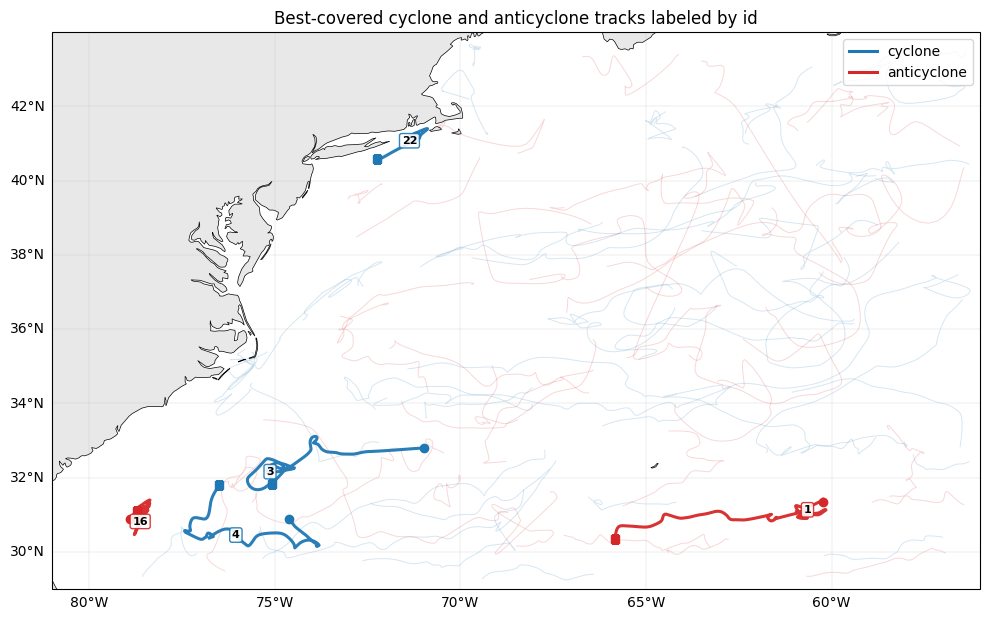

In [96]:
pace_date_counts = (
    pigments.groupby(["polarity", "track_id"])["date"]
    .nunique()
    .reset_index(name="pace_dates")
)
top_cyclones = (
    pace_date_counts[pace_date_counts["polarity"] == "cyclone"]
    .sort_values(["pace_dates", "track_id"], ascending=[False, True])
    .head(3)
)
top_anticyclones = (
    pace_date_counts[pace_date_counts["polarity"] == "anticyclone"]
    .sort_values(["pace_dates", "track_id"], ascending=[False, True])
    .head(2)
)
SELECTED_EDDIES = [
    *list(top_cyclones[["polarity", "track_id"]].itertuples(index=False, name=None)),
    *list(top_anticyclones[["polarity", "track_id"]].itertuples(index=False, name=None)),
]
selected_lookup = set(SELECTED_EDDIES)

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-81, -56, 29, 44], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e8e8")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

for pol in ("cyclone", "anticyclone"):
    sub = track_properties[track_properties["polarity"] == pol]
    for tid, grp in sub.sort_values("date").groupby("track_id"):
        is_selected = (pol, int(tid)) in selected_lookup
        ax.plot(
            grp["center_lon"],
            grp["center_lat"],
            color=COLORS[pol],
            lw=2.2 if is_selected else 0.7,
            alpha=0.95 if is_selected else 0.18,
            transform=ccrs.PlateCarree(),
            zorder=3 if is_selected else 1,
        )
        if is_selected:
            ax.plot(
                grp["center_lon"].iloc[0],
                grp["center_lat"].iloc[0],
                "o",
                color=COLORS[pol],
                ms=6,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )
            ax.plot(
                grp["center_lon"].iloc[-1],
                grp["center_lat"].iloc[-1],
                "s",
                color=COLORS[pol],
                ms=6,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

for pol, tid in SELECTED_EDDIES:
    grp = (
        track_properties[
            (track_properties["polarity"] == pol)
            & (track_properties["track_id"] == tid)
        ]
        .sort_values("date")
        .copy()
    )
    label_idx = len(grp) // 2
    ax.text(
        grp["center_lon"].iloc[label_idx],
        grp["center_lat"].iloc[label_idx],
        str(tid),
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor=COLORS[pol],
            alpha=0.9,
        ),
        zorder=5,
    )

for pol in ("cyclone", "anticyclone"):
    ax.plot([], [], color=COLORS[pol], lw=2.2, label=pol)

ax.set_title("Best-covered cyclone and anticyclone tracks labeled by id")
ax.legend(loc="upper right")
fig.tight_layout()


![](images/2026-03-25-09-17-08.png)

TODO:
- Plot eddies individually for cyclonic/anticyclonic, see if eddies of the same polarity have a similar shape over their lifetime
    - time on x axis, tchla on y
    - then try normalization based on whole lifetime

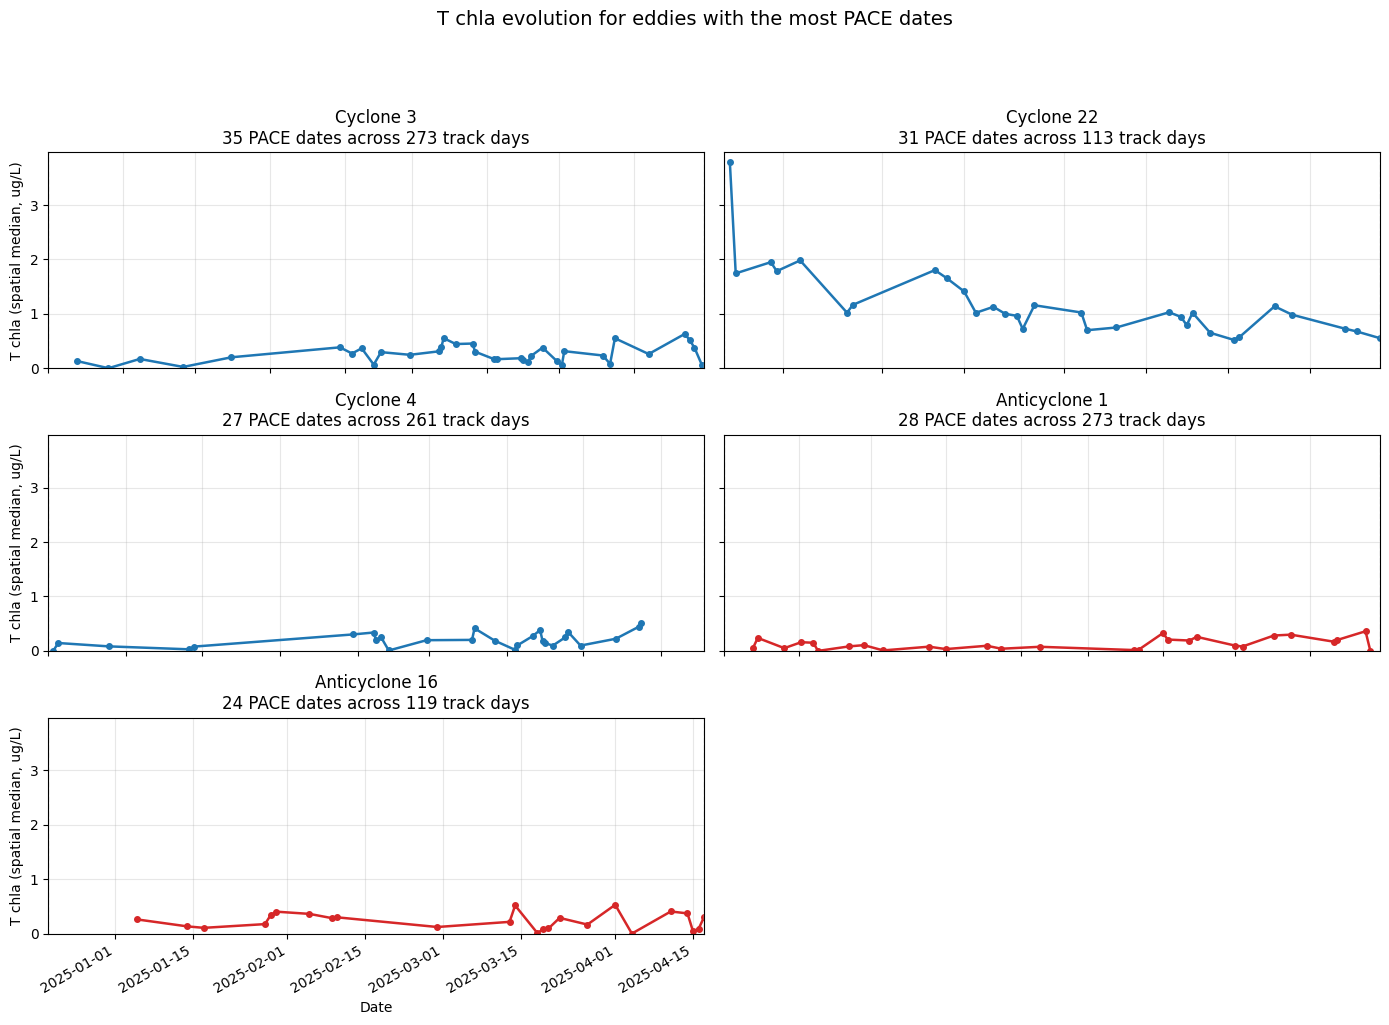

In [97]:
if "SELECTED_EDDIES" not in globals():
    pace_date_counts = (
        pigments.groupby(["polarity", "track_id"])["date"]
        .nunique()
        .reset_index(name="pace_dates")
    )
    top_cyclones = (
        pace_date_counts[pace_date_counts["polarity"] == "cyclone"]
        .sort_values(["pace_dates", "track_id"], ascending=[False, True])
        .head(3)
    )
    top_anticyclones = (
        pace_date_counts[pace_date_counts["polarity"] == "anticyclone"]
        .sort_values(["pace_dates", "track_id"], ascending=[False, True])
        .head(2)
    )
    SELECTED_EDDIES = [
        *list(top_cyclones[["polarity", "track_id"]].itertuples(index=False, name=None)),
        *list(top_anticyclones[["polarity", "track_id"]].itertuples(index=False, name=None)),
    ]

eddy_tchla = (
    pigments.groupby(["polarity", "track_id", "date"])["T chla"]
    .median()
    .reset_index(name="tchla_median")
)

track_windows = (
    track_properties.groupby(["polarity", "track_id"])["date"]
    .agg(track_start="min", track_end="max")
    .reset_index()
)
track_windows["lifetime_days"] = (
    track_windows["track_end"] - track_windows["track_start"]
).dt.days + 1

selected_meta = pd.DataFrame(
    SELECTED_EDDIES,
    columns=["polarity", "track_id"],
).merge(track_windows, on=["polarity", "track_id"], how="left")
global_max = (
    eddy_tchla.merge(
        pd.DataFrame(SELECTED_EDDIES, columns=["polarity", "track_id"]),
        on=["polarity", "track_id"],
        how="inner",
    )["tchla_median"].max()
)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for idx, ((pol, tid), ax) in enumerate(zip(SELECTED_EDDIES, axes)):
    meta = selected_meta[
        (selected_meta["polarity"] == pol)
        & (selected_meta["track_id"] == tid)
    ].iloc[0]
    grp = (
        eddy_tchla[
            (eddy_tchla["polarity"] == pol)
            & (eddy_tchla["track_id"] == tid)
        ]
        .sort_values("date")
        .copy()
    )

    ax.plot(
        grp["date"],
        grp["tchla_median"],
        "o-",
        color=COLORS[pol],
        lw=1.8,
        ms=4,
    )
    ax.set_xlim(meta["track_start"], meta["track_end"])
    ax.axvline(meta["track_start"], color="0.85", linestyle="--", lw=1)
    ax.axvline(meta["track_end"], color="0.85", linestyle="--", lw=1)
    ax.grid(alpha=0.3)
    ax.set_title(
        f"{pol.capitalize()} {tid}\n"
        f"{len(grp)} PACE dates across {int(meta['lifetime_days'])} track days"
    )
    if len(grp) < 3:
        ax.text(
            0.02,
            0.95,
            "Sparse PACE coverage",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color="0.35",
        )
    if idx % 2 == 0:
        ax.set_ylabel("T chla (spatial median, ug/L)")
    if idx >= 3:
        ax.set_xlabel("Date")

for ax in axes[len(SELECTED_EDDIES):]:
    ax.remove()

for ax in axes[:len(SELECTED_EDDIES)]:
    ax.set_ylim(0, global_max * 1.05)

fig.suptitle("T chla evolution for eddies with the most PACE dates", y=1.02, fontsize=14)
fig.autofmt_xdate(rotation=30, ha="right")
fig.tight_layout(rect=[0, 0, 1, 0.97])


## Eddy lifetime Tchla trajectories

Per-eddy T chla trajectories plotted against normalized eddy lifetime (0 = first observation, 1 = last). Each thin line traces one eddy's spatial median T chla across PACE observation dates. Only eddies with lifetime ≥ 60 days are included; gaps correspond to dates without valid PACE retrievals.

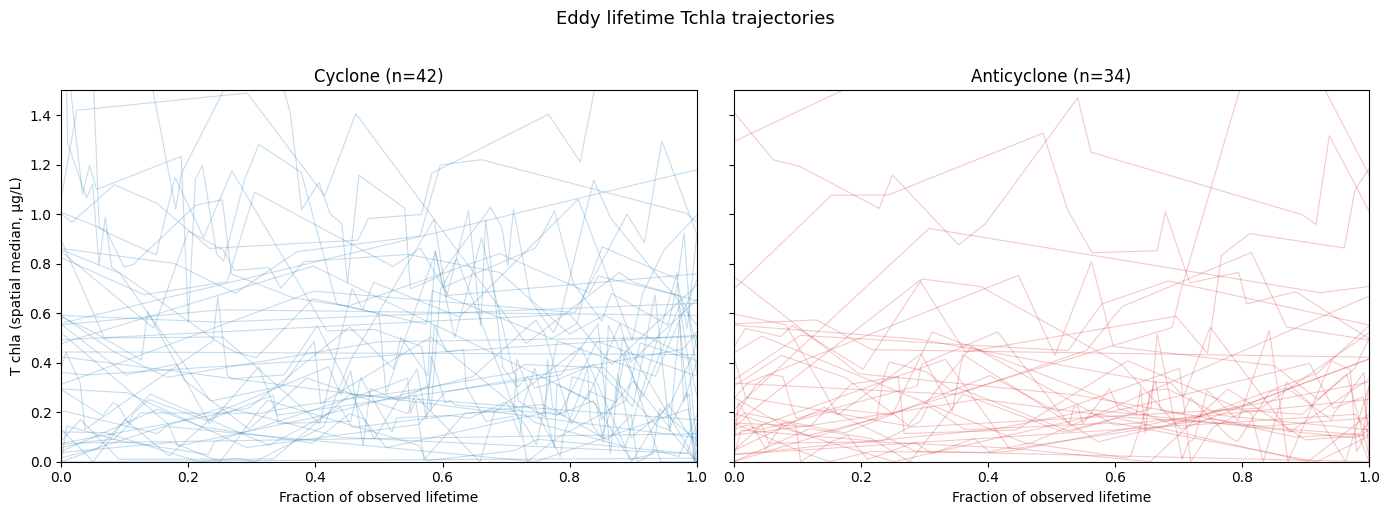

In [98]:
# Per-eddy-date spatial median Tchla
eddy_medians = (
    pigments.groupby(["track_id", "date", "polarity"])["T chla"]
    .median()
    .reset_index()
)

# Normalized eddy age: 0 = first observation, 1 = last
date_range = (
    eddy_medians.groupby(["track_id", "polarity"])["date"]
    .agg(["min", "max"])
    .rename(columns={"min": "first_date", "max": "last_date"})
    .reset_index()
)
eddy_medians = eddy_medians.merge(date_range, on=["track_id", "polarity"])

span = (eddy_medians["last_date"] - eddy_medians["first_date"]).dt.total_seconds()
elapsed = (eddy_medians["date"] - eddy_medians["first_date"]).dt.total_seconds()
eddy_medians["age_frac"] = np.where(span > 0, elapsed / span, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pol in zip(axes, ("cyclone", "anticyclone")):
    sub = eddy_medians[eddy_medians["polarity"] == pol]

    for tid, grp in sub.sort_values("age_frac").groupby("track_id"):
        ax.plot(grp["age_frac"], grp["T chla"],
                color=COLORS[pol], alpha=0.25, lw=0.8)

    ax.set_title(f"{pol.capitalize()} (n={sub['track_id'].nunique()})")
    ax.set_xlabel("Fraction of observed lifetime")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.5)

axes[0].set_ylabel("T chla (spatial median, µg/L)")
fig.suptitle("Eddy lifetime Tchla trajectories", y=1.02, fontsize=13)
fig.tight_layout()

Figure out why there's sudden jumps and fewer points than we think should be there.

Pick out a smaller number of eddies.



## Daily concentration time series

Daily mean T chla and PFT concentration per polarity, averaged across all eddies observed on each date. Two-level averaging (pixel → eddy mean, then eddy means → daily mean) ensures each eddy contributes equally regardless of size. Blue = cyclonic, red = anticyclonic.

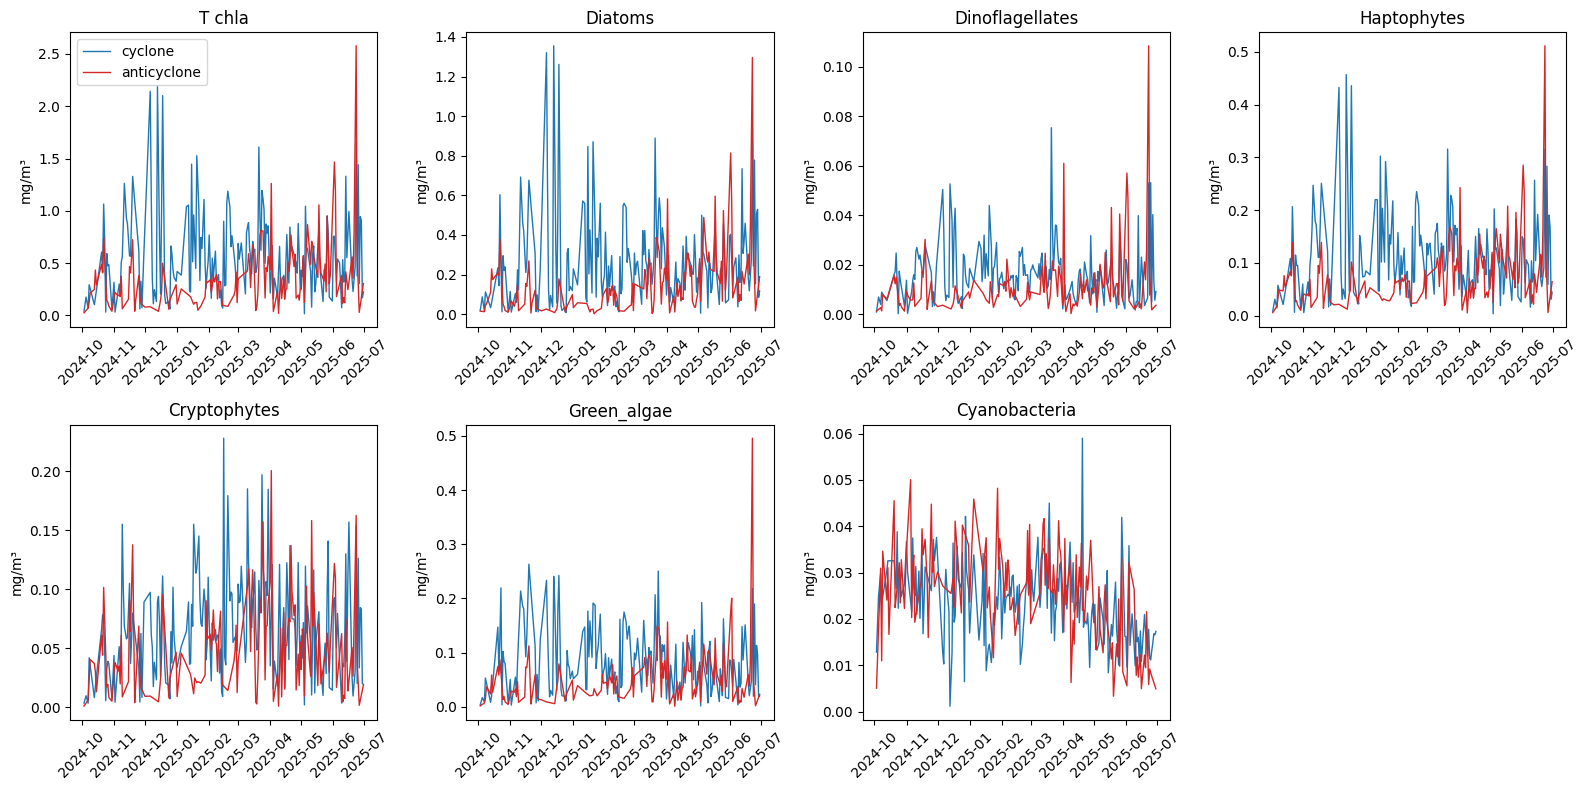

In [99]:
# Daily mean T chla (mean of per-eddy means, already in eddy_means)
daily_tchla = (
    eddy_means.groupby(["date", "polarity"])["T chla"]
    .mean()
    .reset_index()
)

# Daily mean PFTs (pixels → eddy mean, then mean across eddies)
pft_eddy_means = (
    pfts.groupby(["track_id", "date", "polarity"])[PFT_COLS]
    .mean()
    .reset_index()
)
daily_pfts = (
    pft_eddy_means.groupby(["date", "polarity"])[PFT_COLS]
    .mean()
    .reset_index()
)

all_cols = ["T chla"] + PFT_COLS
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(all_cols):
    ax = axes.flat[i]
    for pol in ("cyclone", "anticyclone"):
        color = "tab:blue" if pol == "cyclone" else "tab:red"
        if col == "T chla":
            sub = daily_tchla[daily_tchla["polarity"] == pol].sort_values("date")
        else:
            sub = daily_pfts[daily_pfts["polarity"] == pol].sort_values("date")
        ax.plot(sub["date"], sub[col], color=color, label=pol, lw=1)
    ax.set_title(col)
    ax.set_ylabel("mg/m³")
    ax.tick_params(axis="x", rotation=45)

axes.flat[0].legend()
axes.flat[-1].set_visible(False)
fig.tight_layout()